In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from collections import defaultdict
import math


In [8]:
# Load the data
data = pd.read_csv('product_data.csv')
data.head()

,product_name,sales,price,reorder_quantity,stock_level,holding_cost,Production_cost,currency_fluctuation,stockout,timestamp
0,Water,54,12.87,57,57,4.58,1.70,-1.51,0,30/9/2024
1,Sauces and Soups,61,3.88,68,140,2.85,2.18,-1.95,0,30/9/2024
2,Instant Porridge,50,16.62,54,400,3.21,1.45,-0.07,0,30/9/2024
3,Biscuits,60,7.84,63,17,2.51,3.96,1.42,0,30/9/2024
4,Water,59,18.48,64,450,4.98,8.80,-1.84,1,29/9/2024


In [9]:
# Preprocess the data
data['timestamp'] = pd.to_datetime(data['timestamp'], format='%d/%m/%Y')
data.dropna(inplace=True)

data.head()

,product_name,sales,price,reorder_quantity,stock_level,holding_cost,Production_cost,currency_fluctuation,stockout,timestamp
0,Water,54,12.87,57,57,4.58,1.70,-1.51,0,2024-09-30
1,Sauces and Soups,61,3.88,68,140,2.85,2.18,-1.95,0,2024-09-30
2,Instant Porridge,50,16.62,54,400,3.21,1.45,-0.07,0,2024-09-30
3,Biscuits,60,7.84,63,17,2.51,3.96,1.42,0,2024-09-30
4,Water,59,18.48,64,450,4.98,8.80,-1.84,1,2024-09-29


In [10]:
data.shape

(4986, 10)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4986 entries, 0 to 4985
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   product_name          4986 non-null   object        
 1   sales                 4986 non-null   int64         
 2   price                 4986 non-null   float64       
 3   reorder_quantity      4986 non-null   int64         
 4   stock_level           4986 non-null   int64         
 5   holding_cost          4986 non-null   float64       
 6   Production_cost       4986 non-null   float64       
 7   currency_fluctuation  4986 non-null   float64       
 8   stockout              4986 non-null   int64         
 9   timestamp             4986 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(4), object(1)
memory usage: 389.7+ KB


In [12]:
# Preprocess the data
data['date'] = pd.to_datetime(data['timestamp'], format='%d/%m/%Y').dt.date
data.head()

,product_name,sales,price,reorder_quantity,stock_level,holding_cost,Production_cost,currency_fluctuation,stockout,timestamp,date
0,Water,54,12.87,57,57,4.58,1.70,-1.51,0,2024-09-30,2024-09-30
1,Sauces and Soups,61,3.88,68,140,2.85,2.18,-1.95,0,2024-09-30,2024-09-30
2,Instant Porridge,50,16.62,54,400,3.21,1.45,-0.07,0,2024-09-30,2024-09-30
3,Biscuits,60,7.84,63,17,2.51,3.96,1.42,0,2024-09-30,2024-09-30
4,Water,59,18.48,64,450,4.98,8.80,-1.84,1,2024-09-29,2024-09-29


In [13]:
# Split the data into training and testing sets
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

# Print the shapes of the datasets
print(f"Training Features shape: {train_data.shape}")  # Training features shape
print(f"Testing Features shape: {test_data.shape}")    # Testing features shape

# Set display options to avoid scientific notation
pd.set_option('display.float_format', '{:.2f}'.format)

# Calculate and print totals for each column in the training dataset
print("\nTotals for Training Dataset:")
print(train_data.sum(numeric_only=True))

# Calculate and print totals for each column in the testing dataset
print("\nTotals for Testing Dataset:")
print(test_data.sum(numeric_only=True))


Training Features shape: (3988, 11)
Testing Features shape: (998, 11)

Totals for Training Dataset:
sales                  199326.00
price                   41792.09
reorder_quantity       217277.00
stock_level            988501.00
holding_cost            10993.14
Production_cost         21916.51
currency_fluctuation     -194.58
stockout                 2024.00
dtype: float64

Totals for Testing Dataset:
sales                   49853.00
price                   10582.16
reorder_quantity        54432.00
stock_level            245727.00
holding_cost             2747.29
Production_cost          5536.65
currency_fluctuation       -8.34
stockout                  504.00
dtype: float64


In [15]:
train_data.describe().T

,count,mean,min,25%,50%,75%,max,std
sales,3988.00,49.98,27.00,45.00,50.00,55.00,76.00,7.21
price,3988.00,10.48,1.01,5.60,10.50,15.34,20.00,5.54
reorder_quantity,3988.00,54.48,28.00,49.00,54.00,60.00,84.00,7.78
stock_level,3988.00,247.87,0.00,123.00,247.00,372.00,499.00,145.42
holding_cost,3988.00,2.76,0.50,1.60,2.78,3.89,5.00,1.30
Production_cost,3988.00,5.50,1.00,3.24,5.46,7.73,9.98,2.60
currency_fluctuation,3988.00,-0.05,-2.00,-1.05,-0.08,0.96,2.00,1.16
stockout,3988.00,0.51,0.00,0.00,1.00,1.00,1.00,0.50
timestamp,3988,2023-01-15 01:59:09.448344832,2021-03-28 00:00:00,2022-03-17 00:00:00,2023-01-11 12:00:00,2023-11-18 00:00:00,2024-09-30 00:00:00,NaN


                      sales  price  reorder_quantity  stock_level  \
sales                  1.00   0.01              0.93        -0.01   
price                  0.01   1.00              0.01         0.03   
reorder_quantity       0.93   0.01              1.00        -0.01   
stock_level           -0.01   0.03             -0.01         1.00   
holding_cost           0.01  -0.01              0.01        -0.03   
Production_cost        0.00  -0.01              0.01         0.00   
currency_fluctuation   0.03   0.00              0.03         0.01   
stockout               0.02  -0.02              0.02         0.01   

                      holding_cost  Production_cost  currency_fluctuation  \
sales                         0.01             0.00                  0.03   
price                        -0.01            -0.01                  0.00   
reorder_quantity              0.01             0.01                  0.03   
stock_level                  -0.03             0.00                  0

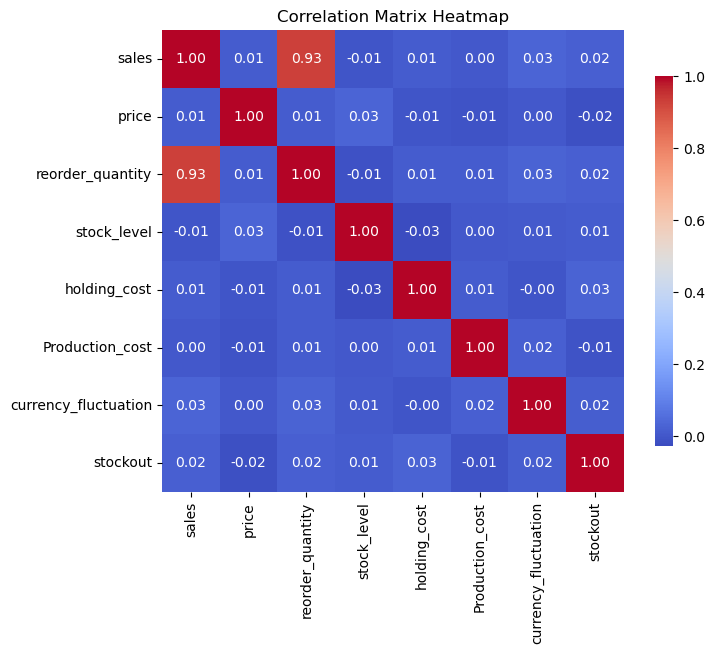

In [16]:
# Step 1: Filter numeric columns
numeric_data = train_data.select_dtypes(include=['number'])

# Step 2: Calculate the correlation matrix
correlation_matrix = numeric_data.corr()

# Display the correlation matrix
print(correlation_matrix)

# Step 3: Draw the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix Heatmap')
plt.show()

In [17]:
# Define the environment for reinforcement learning
class InventoryEnv:
    def __init__(self, data):
        self.data = data.reset_index(drop=True)
        self.current_index = 0
        self.total_cost = 0
        self.state = None

    def reset(self):
        self.current_index = 0
        self.total_cost = 0
        self.state = self.data.iloc[self.current_index]
        return self.state

    def step(self, action):
        sales = self.state['sales']
        holding_cost = self.state['holding_cost'] * max(0, self.state['stock_level'] + action - sales)
        production_cost = self.state['Production_cost'] * action

        
        # Update total cost
        self.total_cost += holding_cost + production_cost
        
        # Move to next time step
        self.current_index += 1
        
        if self.current_index < len(self.data):
            self.state = self.data.iloc[self.current_index]
            return self.state, self.total_cost
        else:
            return None, self.total_cost  # End of episodes

In [18]:
# Q-learning parameters
alpha = 0.01    
gamma = 0.995      
epsilon = 1.0    
epsilon_decay = 0.99
min_epsilon = 0.1
num_episodes = 100

In [19]:
# List to store total rewards for each episode
total_rewards = []

In [20]:
# Initialize Q-table
q_table = defaultdict(lambda: np.zeros(59))  # Assuming max reorder quantity of 58
# Training the Q-learning model
env = InventoryEnv(train_data)
for episode in range(num_episodes):
    state = env.reset()
    total_reward = 0
    
    while True:
        # Choose action (epsilon-greedy strategy)
        if np.random.rand() < epsilon:
            action = np.random.randint(0, 59)  # Random action
        else:
            action = np.argmax(q_table[(state['product_name'], state['stock_level'])])
        
        next_state, total_cost= env.step(action)
        
        # Update Q-value
        if next_state is not None:
            q_table[(state['product_name'], state['stock_level'])][action] += alpha * (
                total_cost + gamma * np.max(q_table[(next_state['product_name'], next_state['stock_level'])]) - 
                q_table[(state['product_name'], state['stock_level'])][action]
            )
        
        state = next_state
        if state is None:
            break
    
    # Epsilon decay
    if epsilon > min_epsilon:
        epsilon *= epsilon_decay

In [21]:
# Initialize a list to store the results
results = []


count_zero_stock = 0

for index, row in test_data.iterrows():
      
    action = np.argmax(q_table[(row['product_name'], row['stock_level'])])
      
    new_stock_level = max(0, row['stock_level'] + action - row['sales'])
    
    # Check if new stock level is 0
    if new_stock_level == 0:
        count_zero_stock += 1
    
    # Append the results to the list
    results.append({
        'Product': row['product_name'],
        'Current Stock Level': row['stock_level'],
        'Sales': row['sales'],
        'Action Taken': action,
        'New Stock Level': new_stock_level
    })

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Print the results in table format
print('-------- Action Taken With New Stock Levels --------')
print(results_df.to_string(index=False))  # Print without row indices



-------- Action Taken With New Stock Levels --------
         Product  Current Stock Level  Sales  Action Taken  New Stock Level
Sauces and Soups                  424     47             0              377
Instant Porridge                  341     51            26              316
Sauces and Soups                  270     49            27              248
           Water                  219     43             0              176
           Water                  406     47            35              394
Sauces and Soups                  378     30            47              395
Sauces and Soups                   68     46            34               56
Sauces and Soups                  294     51             0              243
        Biscuits                  486     51            11              446
Instant Porridge                  345     55            22              312
           Water                  469     34            49              484
Sauces and Soups                   

In [22]:

# Print the count of instances where new stock level is 0
print(f"Number of instances where new stock level is 0: {count_zero_stock}")

Number of instances where new stock level is 0: 56


In [23]:
# Testing the model
total_cost_before = (test_data['holding_cost']* test_data['stock_level']).sum() + (test_data['Production_cost']* test_data['stock_level']).sum()

total_cost_after = 0
for index, row in test_data.iterrows():
    action = np.argmax(q_table[(row['product_name'], row['stock_level'])])
    holding_cost = row['holding_cost'] * max(0, row['stock_level'] + action - row['sales'])
    production_cost = row['Production_cost'] * action
    total_cost_after += holding_cost + production_cost
    
print(f"Total Cost Before: {total_cost_before}")
print(f"Total Cost After: {total_cost_after}")
    

Total Cost Before: 2030122.36
Total Cost After: 760016.0799999995


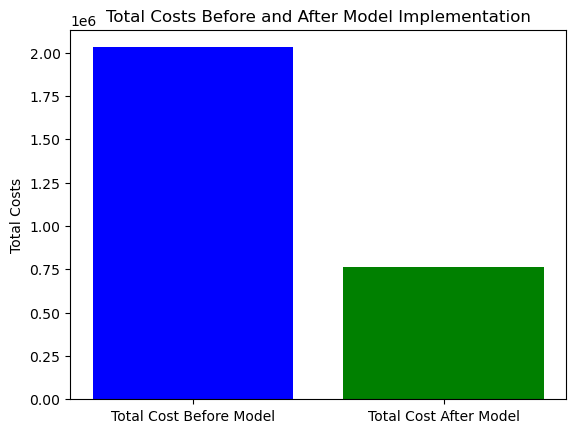

In [24]:
# Visualization of costs
def plot_costs(before_costs, after_costs):
    labels = ['Total Cost Before Model', 'Total Cost After Model']
    costs = [before_costs, after_costs]

    plt.bar(labels, costs, color=['blue', 'green'])
    plt.ylabel('Total Costs')
    plt.title('Total Costs Before and After Model Implementation')
    plt.show()

plot_costs(total_cost_before, total_cost_after)

In [27]:
def calculate_eoq(demand_rate, ordering_cost, holding_cost):
    """Calculate the Economic Order Quantity (EOQ)."""
    eoq = math.sqrt((2 * D * O) / H)
    return eoq

In [28]:
# Function to calculate EOQ
def calculate_eoq(row):
    D = row['sales']
    H = row['holding_cost']
    O = row['Production_cost']
    if H > 0:  
         eoq = math.sqrt((2 * D * O) / H)
         return eoq
    return 0
    

In [29]:
# Apply the function to each row in the DataFrame
test_data['EOQ'] = test_data.apply(calculate_eoq, axis=1)

In [30]:
# Display the test_data with EOQ
print(test_data)

          product_name  sales  price  reorder_quantity  stock_level  \
1489  Sauces and Soups     47   9.77                53          424   
2754  Instant Porridge     51   5.36                60          341   
465   Sauces and Soups     49   2.17                54          270   
2488             Water     43   5.08                47          219   
676              Water     47  17.65                54          406   
...                ...    ...    ...               ...          ...   
879           Biscuits     50  10.44                51          142   
1942  Instant Porridge     59  17.41                61          111   
4856             Water     49  17.80                52           54   
4357  Sauces and Soups     53   8.49                54          472   
1448             Water     47   2.62                49          370   

      holding_cost  Production_cost  currency_fluctuation  stockout  \
1489          4.70             3.24                  0.27         0   
2754 

In [31]:

# Function to calculate total cost for EOQ
def calculate_total_cost_eoq(row):
    D = row['sales']  # Demand
    H = row['holding_cost']  # Holding cost
    O = row['Production_cost']  # Production cost
    EOQ = row['EOQ']  # EOQ from previous calculation

    # Calculate total cost only if EOQ is greater than zero
    if EOQ > 0:
        total_cost_EOQ = (H * row['stock_level']) + (O * EOQ)
        return total_cost_EOQ
    return 0

# Apply the function to calculate total costs for EOQ
test_data['TotalCost_EOQ'] = test_data.apply(calculate_total_cost_eoq, axis=1)



In [32]:
# Display the test_data with EOQ and Total Costs
print(test_data[['sales', 'holding_cost', 'Production_cost', 'stock_level', 'EOQ', 'TotalCost_EOQ']])

      sales  holding_cost  Production_cost  stock_level   EOQ  TotalCost_EOQ
1489     47          4.70             3.24          424  8.05        2018.88
2754     51          3.80             6.00          341 12.69        1371.94
465      49          0.58             5.91          270 31.60         343.36
2488     43          1.60             1.73          219  9.64         367.08
676      47          3.10             2.27          406  8.30        1277.43
...     ...           ...              ...          ...   ...            ...
879      50          3.49             7.23          142 14.39         599.64
1942     59          4.18             9.42          111 16.31         617.59
4856     49          1.46             2.92           54 14.00         119.72
4357     53          3.90             3.47          472  9.71        1874.50
1448     47          0.88            10.00          370 32.68         652.43

[998 rows x 6 columns]


Total Cost After: 760016.0799999995
Total Cost EOQ: 781594.7863928797


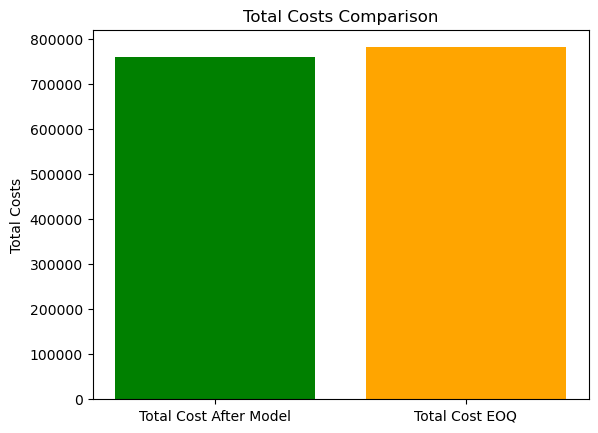

In [33]:
# Visualization of costs

# Total cost using EOQ
total_cost_eoq = test_data['TotalCost_EOQ'].sum()

def plot_costs(after_costs, eoq_costs):
    labels = ['Total Cost After Model', 'Total Cost EOQ']
    costs = [after_costs, eoq_costs]

    plt.bar(labels, costs, color=['green', 'orange'])
    plt.ylabel('Total Costs')
    plt.title('Total Costs Comparison')
    plt.show()
    
print(f"Total Cost After: {total_cost_after}")
print(f"Total Cost EOQ: {total_cost_eoq}")
        

plot_costs(total_cost_after, total_cost_eoq)

In [34]:
# Calculate MAE 
mae = np.abs(results_df['New Stock Level'] - results_df['Sales']).mean() 
# # Print MAE 
print(f'Mean Absolute Error (MAE): {mae}')

Mean Absolute Error (MAE): 183.62925851703406
